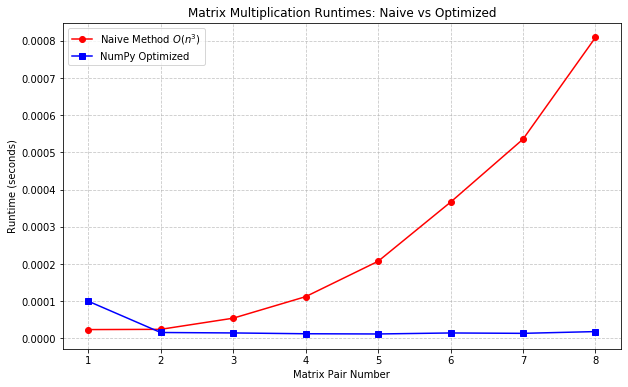

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt

# 1. Custom naive function from the lecture
def naive_matrix_multiplication(A, B):
    n = len(A)
    # Initialize the result matrix C with zeros
    C = [[0] * n for _ in range(n)]
    
    # Three nested loops resulting in O(n^3) time complexity
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

def main():
    # 2. Build 8 pairs of matrices
    # We will use square matrices to ensure compatibility with the naive function above.
    # Sizes: 2x2, 4x4, 6x6, 8x8, 10x10, 12x12, 14x14, 16x16
    matrix_sizes = [2, 4, 6, 8, 10, 12, 14, 16]
    
    naive_runtimes = []
    numpy_runtimes = []
    pair_numbers = list(range(1, 9))

    for n in matrix_sizes:
        # Generate random matrices
        # Converting to standard Python lists for the naive function
        A_list = np.random.rand(n, n).tolist()
        B_list = np.random.rand(n, n).tolist()
        
        # Keeping as NumPy arrays for the optimized function
        A_np = np.array(A_list)
        B_np = np.array(B_list)

        # 3. Time the naive matrix multiplication
        start_time = time.perf_counter()
        naive_matrix_multiplication(A_list, B_list)
        naive_end_time = time.perf_counter()
        naive_runtimes.append(naive_end_time - start_time)

        # 4. Time the optimized NumPy matrix multiplication
        start_time = time.perf_counter()
        np.dot(A_np, B_np) 
        numpy_end_time = time.perf_counter()
        numpy_runtimes.append(numpy_end_time - start_time)

    # 5. Plot the runtimes
    plt.figure(figsize=(10, 6))
    plt.plot(pair_numbers, naive_runtimes, marker='o', label='Naive Method $O(n^3)$', color='red')
    plt.plot(pair_numbers, numpy_runtimes, marker='s', label='NumPy Optimized', color='blue')
    
    plt.title('Matrix Multiplication Runtimes: Naive vs Optimized')
    plt.xlabel('Matrix Pair Number')
    plt.ylabel('Runtime (seconds)')
    plt.xticks(pair_numbers)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Display the plot
    plt.show()

if __name__ == "__main__":
    main()